In [5]:
import numpy as np
import pandas as pd
import scanpy as sc

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

import scipy.sparse as sp

In [6]:
# -----------------------------
# Load data
# -----------------------------

adata = sc.read_h5ad("M_smartsva_corrected_with_SH_annot_filtered.h5ad")

phase_col = "cycle-phase"

secretory_phases = ["ESE", "MSE", "LSE", "SE"]
proliferative_phases = ["PE", "MPE", "LPE"]

keep_phases = secretory_phases + proliferative_phases

adata_binary = adata[
    adata.obs[phase_col].isin(keep_phases)
].copy()

adata_binary.obs["phase_binary"] = (
    adata_binary.obs[phase_col].isin(secretory_phases).astype(int)
)

X = adata_binary.X
y = adata_binary.obs["phase_binary"].astype(int).values

if sp.issparse(X):
    X = X.tocsr()

In [7]:
# -----------------------------
# Best C from main model
# -----------------------------

best_C = 0.001000   # replace with your best value


===== PERMUTATION 1/10 =====


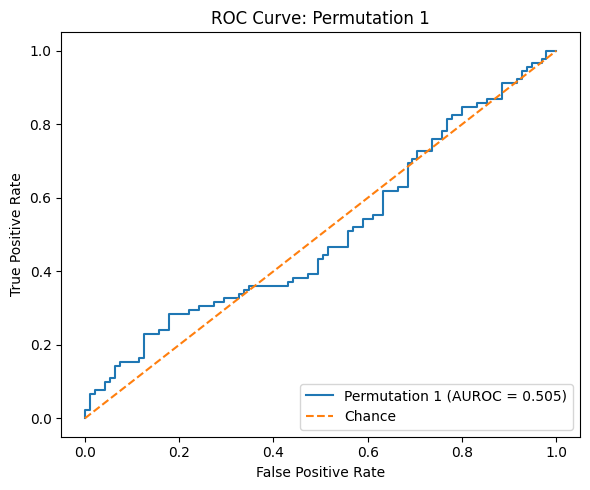


===== PERMUTATION 2/10 =====


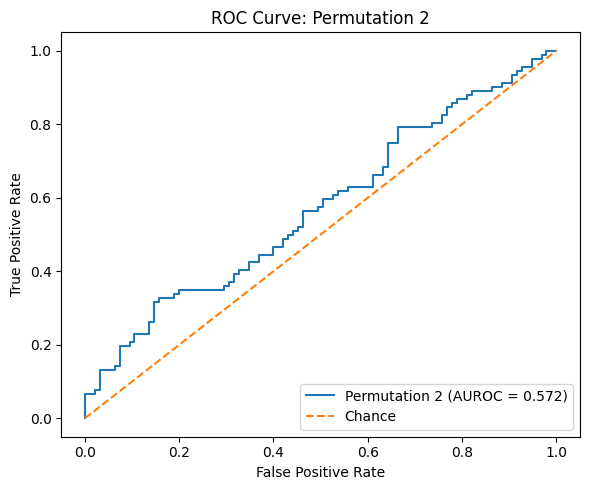


===== PERMUTATION 3/10 =====


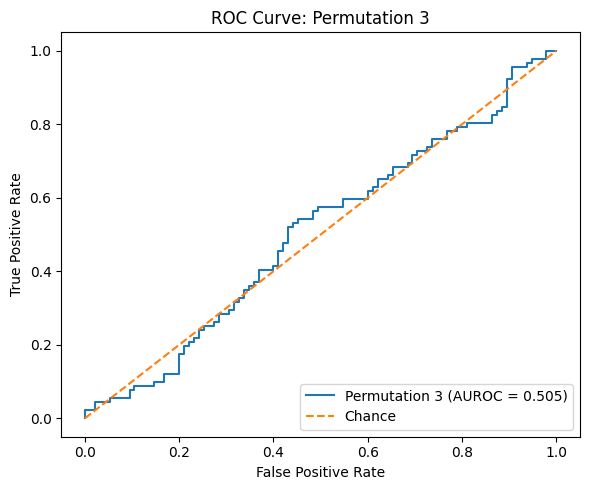


===== PERMUTATION 4/10 =====


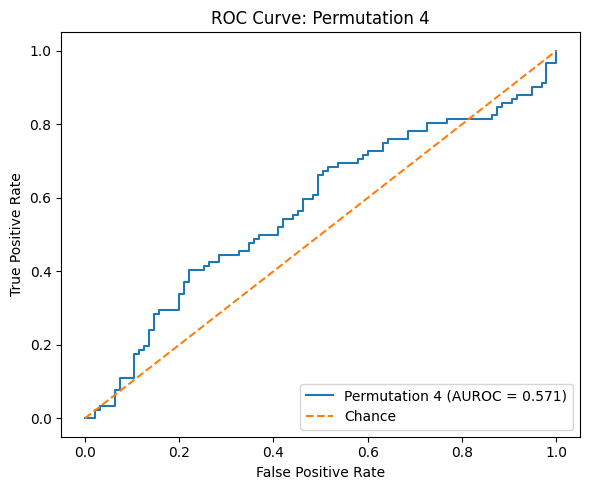


===== PERMUTATION 5/10 =====


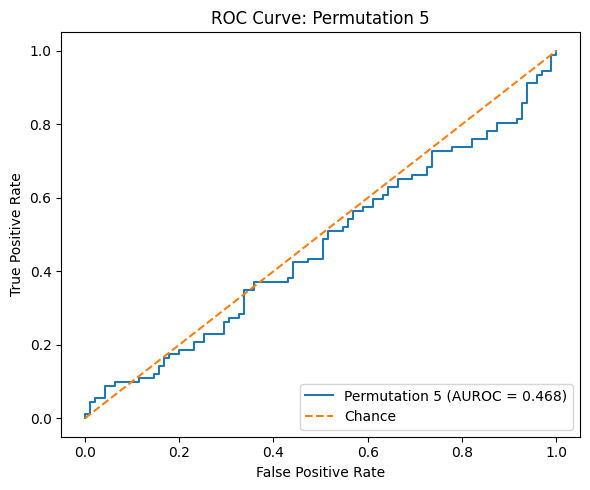


===== PERMUTATION 6/10 =====


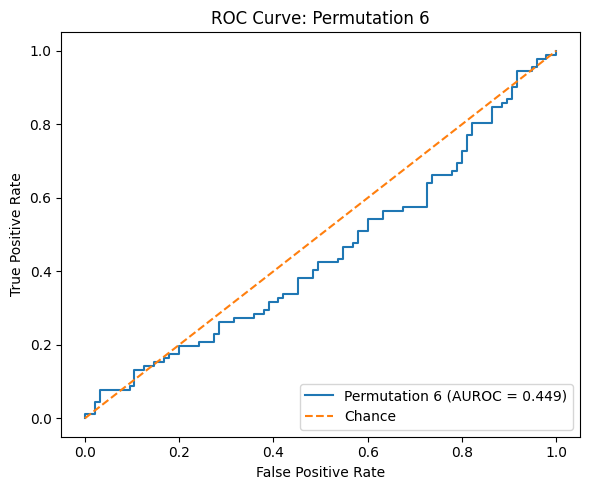


===== PERMUTATION 7/10 =====


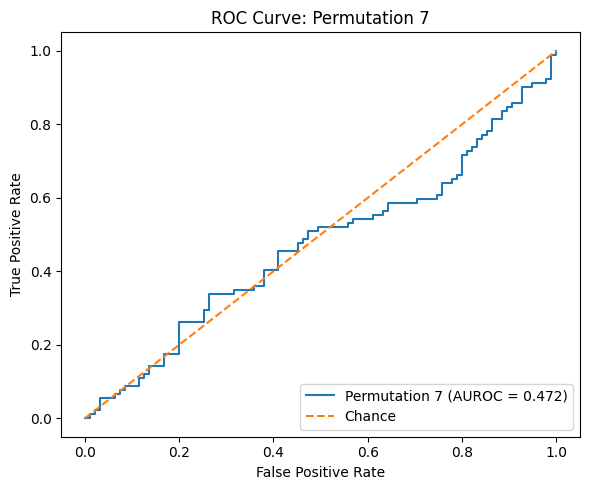


===== PERMUTATION 8/10 =====


/home/ubuntu/.local/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


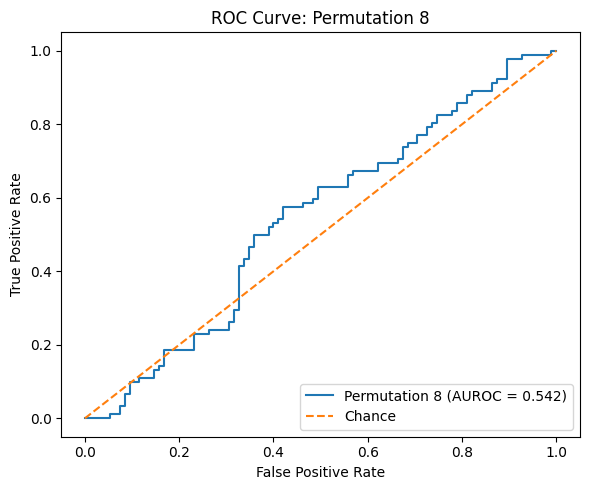


===== PERMUTATION 9/10 =====


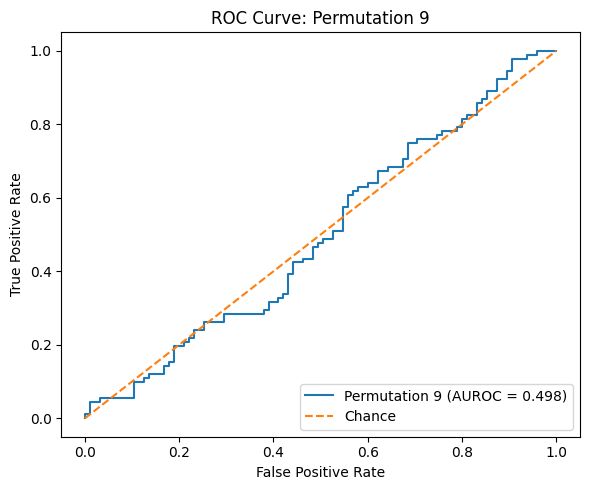


===== PERMUTATION 10/10 =====


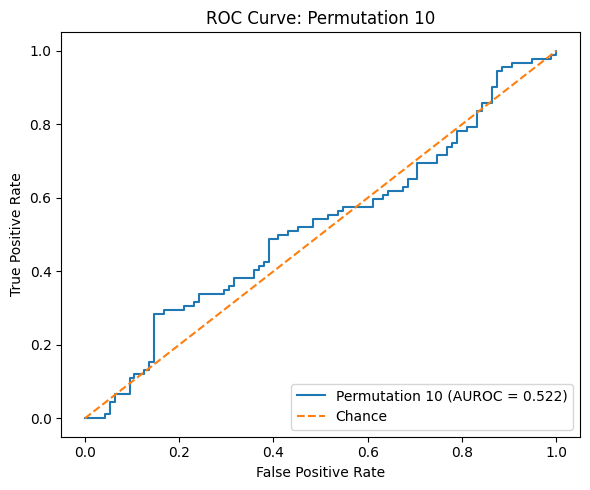


Permutation results:
   perm_run    cv_auc  test_auc  test_auprc  test_precision  test_recall  \
0         1  0.493588  0.504577    0.543434        0.433735     0.391304   
1         2  0.478085  0.571968    0.600020        0.529412     0.586957   
2         3  0.563735  0.504805    0.503382        0.493333     0.402174   
3         4  0.468308  0.571281    0.550443        0.548077     0.619565   
4         5  0.507128  0.467849    0.498802        0.461538     0.391304   
5         6  0.487492  0.448513    0.483130        0.450000     0.489130   
6         7  0.481659  0.471625    0.490416        0.500000     0.510870   
7         8  0.485179  0.542105    0.499632        0.549296     0.423913   
8         9  0.467978  0.497597    0.499274        0.481481     0.423913   
9        10  0.494722  0.521739    0.510120        0.500000     0.554348   

    test_f1  test_acc  
0  0.411429  0.449198  
1  0.556701  0.540107  
2  0.443114  0.502674  
3  0.581633  0.561497  
4  0.423529  0.475936

In [8]:
# -----------------------------
# Permutation testing
# -----------------------------

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

n_permutations = 10
perm_results = []

for i in range(n_permutations):

    print(f"\n===== PERMUTATION {i+1}/{n_permutations} =====")

    y_perm = np.random.permutation(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_perm,
        test_size=0.2,
        stratify=y_perm,
        random_state=42
    )

    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            C=best_C,
            class_weight="balanced",
            max_iter=5000
        ))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=4
    )

    pipe.fit(X_train, y_train)

    test_prob = pipe.predict_proba(X_test)[:, 1]
    test_pred = (test_prob >= 0.5).astype(int)

    test_auc = roc_auc_score(y_test, test_prob)
    test_auprc = average_precision_score(y_test, test_prob)
    test_precision = precision_score(y_test, test_pred)
    test_recall = recall_score(y_test, test_pred)
    test_f1 = f1_score(y_test, test_pred)
    test_acc = accuracy_score(y_test, test_pred)

    fpr, tpr, _ = roc_curve(y_test, test_prob)

    perm_results.append({
        "perm_run": i + 1,
        "cv_auc": cv_scores.mean(),
        "test_auc": test_auc,
        "test_auprc": test_auprc,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1": test_f1,
        "test_acc": test_acc
    })

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"Permutation {i+1} (AUROC = {test_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: Permutation {i+1}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

perm_df = pd.DataFrame(perm_results)

perm_df.to_csv("cycle_phase_permutation_results.csv", index=False)

print("\nPermutation results:")
print(perm_df)